In [90]:
import numpy as np
import matplotlib.pyplot as plt

x = np.arange(0, 1.01, 0.01)
x = np.sort(x)

m_original = np.random.uniform(-6,6)
b_original = np.random.uniform(-5,5)

random_number = np.random.uniform(0,1,len(x))

y = m_original * x + b_original + random_number

In [91]:
#least squares function
def least_squares(x, y):

    n = len(x)

    sum_x = np.sum(x)
    sum_y = np.sum(y)
    sum_xy = np.sum(x*y)
    sum_x2 = np.sum(x**2)

    m = (n*sum_xy - sum_x*sum_y) / (n*sum_x2 - sum_x**2)
    b = (sum_y - m*sum_x) / n

    return m, b

m_custom, b_custom = least_squares(x,y)

In [92]:
#comparison w numpy

A = np.vstack([x, np.ones(len(x))]).T
m_numpy, b_numpy = np.linalg.lstsq(A, y, rcond=None)[0]

In [93]:
#results
print("original equation:")
print("m =", m_original, "b =", b_original)

print("\ncustom least squares:")
print("m =", m_custom, "b =", b_custom)

print("\nnumpy least squares:")
print("m =", m_numpy, "b =", b_numpy)

original equation:
m = -4.186611960763594 b = 1.0705828518159226

custom least squares:
m = -4.214692469833089 b = 1.5531403351080386

numpy least squares:
m = -4.214692469833091 b = 1.5531403351080408


In [94]:
#residuals

predicted_y = m_custom * x + b_custom

residuals = y - predicted_y

max_residual_point = np.argmax(np.abs(residuals))
min_residual_point = np.argmin(np.abs(residuals))

print("\nlargest residual:", residuals[max_residual_point], "at x =", x[max_residual_point])
print("smallest residual:", residuals[min_residual_point], "at x =", x[min_residual_point])



largest residual: 0.533660112504081 at x = 0.76
smallest residual: 1.0511634320309327e-05 at x = 0.93


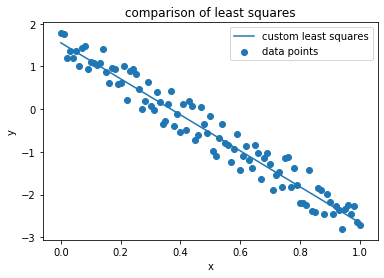

In [95]:
#plotting

plt.scatter(x,y,label="data points")

plt.plot(x,predicted_y,label="custom least squares")

plt.xlabel("x")
plt.ylabel("y")

plt.title("comparison of least squares")

plt.legend()

plt.show()

#### OpenAI. (2026). ChatGPT (GPT-5.3) Prompted ChatGPT to find points for the residuals as well as set up random number and data generation that was used for least squares. 